In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [98]:
# Import Data original
og_1 = pd.read_csv("/content/drive/MyDrive/datasets/index_1.csv")
#Import data penjualan kedua
og_2 = pd.read_csv("/content/drive/MyDrive/datasets/index_2.csv")

In [99]:
#Membuat copy data penjualan pertama
df_1 = pd.read_csv("/content/drive/MyDrive/datasets/index_1.csv")
#Membuat copy data penjualan kedua
df_2 = pd.read_csv("/content/drive/MyDrive/datasets/index_2.csv")

In [100]:
df_1.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


In [101]:
df_2.head()

,date,datetime,cash_type,money,coffee_name
0,2025-02-08,2025-02-08 14:26:04,cash,15.0,Tea
1,2025-02-08,2025-02-08 14:28:26,cash,15.0,Tea
2,2025-02-08,2025-02-08 14:33:04,card,20.0,Espresso
3,2025-02-08,2025-02-08 15:51:04,card,30.0,Chocolate with coffee
4,2025-02-08,2025-02-08 16:35:01,cash,27.0,Chocolate with milk


In [102]:
#Delete column card as it is not needed and not in the 2nd dataset
df_1.drop(["date", "card"], axis=1, inplace=True)

In [103]:
df_2.drop("date", axis=1, inplace=True)

In [104]:
#Cek informasi
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     3636 non-null   object 
 1   cash_type    3636 non-null   object 
 2   money        3636 non-null   float64
 3   coffee_name  3636 non-null   object 
dtypes: float64(1), object(3)
memory usage: 113.8+ KB


In [105]:
#Cek informasi
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     262 non-null    object 
 1   cash_type    262 non-null    object 
 2   money        262 non-null    float64
 3   coffee_name  262 non-null    object 
dtypes: float64(1), object(3)
memory usage: 8.3+ KB


In [106]:
df_1.isnull().sum().sort_values(ascending=False)

,0
datetime,0
cash_type,0
money,0
coffee_name,0


In [107]:
df_2.isnull().sum().sort_values(ascending=False)

,0
datetime,0
cash_type,0
money,0
coffee_name,0


In [108]:
df_1.duplicated().sum()

np.int64(0)

In [109]:
df_2.duplicated().sum()

np.int64(2)

In [110]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     3636 non-null   object 
 1   cash_type    3636 non-null   object 
 2   money        3636 non-null   float64
 3   coffee_name  3636 non-null   object 
dtypes: float64(1), object(3)
memory usage: 113.8+ KB


In [111]:
df_2.drop_duplicates(inplace=True)

In [112]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 0 to 261
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     260 non-null    object 
 1   cash_type    260 non-null    object 
 2   money        260 non-null    float64
 3   coffee_name  260 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.2+ KB


In [113]:
#Merge data pertama dan kedua
full_df = pd.concat([df_1, df_2], ignore_index=True)

In [114]:
full_df

,datetime,cash_type,money,coffee_name
0,2024-03-01 10:15:50.520,card,38.7,Latte
1,2024-03-01 12:19:22.539,card,38.7,Hot Chocolate
2,2024-03-01 12:20:18.089,card,38.7,Hot Chocolate
3,2024-03-01 13:46:33.006,card,28.9,Americano
4,2024-03-01 13:48:14.626,card,38.7,Latte
...,...,...,...,...
3891,2025-03-23 14:55:46,cash,30.0,Cappuccino
3892,2025-03-23 15:15:36,card,25.0,Irish whiskey
3893,2025-03-23 17:59:25,card,28.0,Super chocolate
3894,2025-03-23 18:01:33,card,28.0,Vanilla with Irish whiskey


In [133]:
#Konversi date time menjadi format date and time
full_df["datetime_converted"] = pd.to_datetime(full_df["datetime_converted"], format="mixed")

#Ekstrak jam pada datetime
full_df["hour"] = full_df["datetime_converted"].dt.hour

#Kolom datetime hanya tanggal, bulan dan tahun saja
full_df["datetime_converted"] = full_df["datetime_converted"].dt.strftime("%Y-%m-%d")

In [134]:
full_df.drop("datetime", axis=1, inplace=True)

KeyError: "['datetime'] not found in axis"

In [135]:
full_df.head()

,cash_type,money,coffee_name,hour,datetime_converted
0,card,38.7,Latte,10,2024-03-01
1,card,38.7,Hot Chocolate,12,2024-03-01
2,card,38.7,Hot Chocolate,12,2024-03-01
3,card,28.9,Americano,13,2024-03-01
4,card,38.7,Latte,13,2024-03-01


## Explore data analytics

In [138]:
# Statistics deskriptif
full_df.describe()

,money,hour
count,3896.000000,3896.000000
mean,31.383876,14.206622
std,5.063845,4.214976
min,15.000000,6.000000
25%,27.920000,11.000000
50%,32.820000,14.000000
75%,35.760000,18.000000
max,40.000000,23.000000


array([[<Axes: title={'center': 'money'}>,
        <Axes: title={'center': 'hour'}>]], dtype=object)

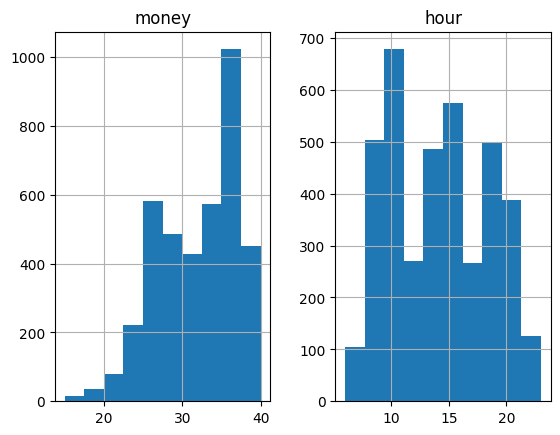

In [139]:
full_df.hist()

<Axes: >

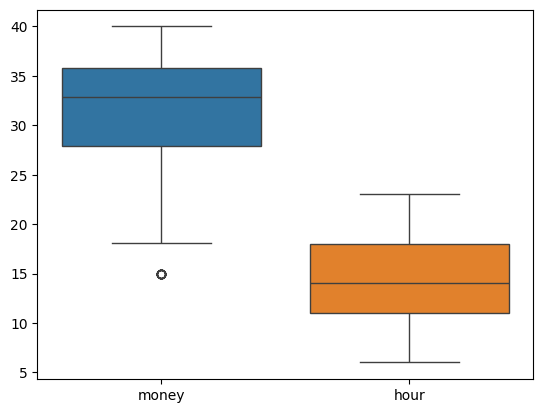

In [140]:
sns.boxplot(data=full_df)

In [141]:
full_df['cash_type'].unique()

array(['card', 'cash'], dtype=object)

<Axes: xlabel='cash_type', ylabel='count'>

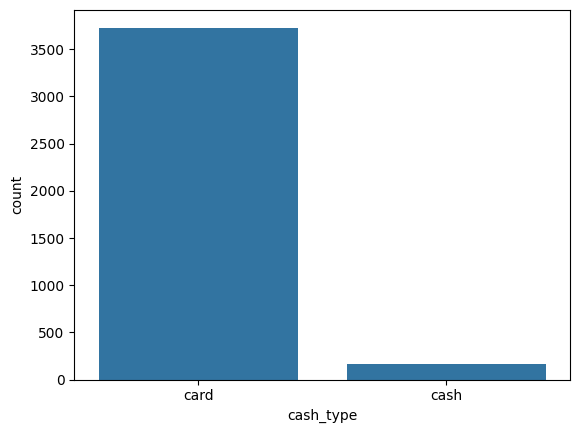

In [142]:
sns.countplot(x="cash_type", data=full_df)

<Axes: xlabel='hour', ylabel='Count'>

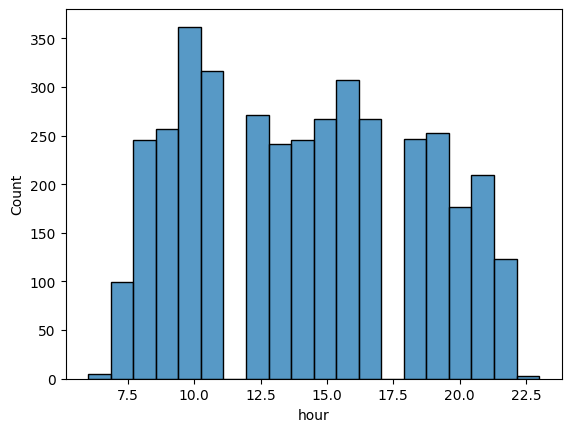

In [143]:
sns.histplot(x="hour", data=full_df)

In [147]:
#Analisis dari bulan
full_df['datetime_converted'] = pd.to_datetime(full_df['datetime_converted'])
full_df['month'] = full_df['datetime_converted'].dt.month

<Axes: xlabel='month', ylabel='count'>

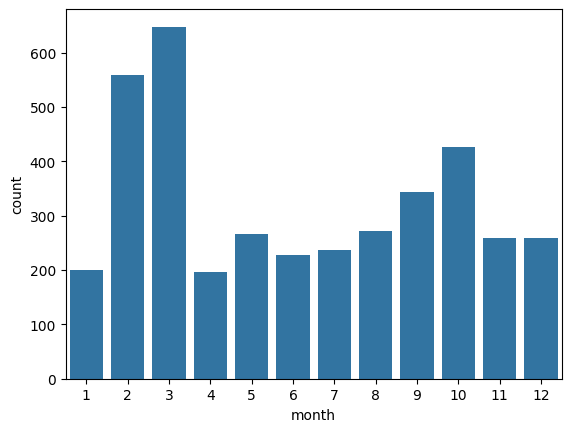

In [149]:
sns.countplot(x="month", data=full_df)